In [3]:
import sys
import os
curr_dir=os.getcwd()
pardir=os.pardir
sys.path.append(os.path.join(curr_dir, pardir))
sys.path.append(os.path.join(curr_dir, pardir, pardir))
# print(f"Current directory: {curr_dir}")
# print(f"Parent directory: {pardir}")
from liset_paper import liset_paper as liset_tk
import numpy as np
import matplotlib.pyplot as plt

from signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns

In [4]:

parent=r"E:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
# print("Available datasets:")
# for i, dataset in enumerate(datasets):
#     print(f"{i}: {dataset}")
# print()
# dataset=int(input("Dataset to process: "))
dataset=2
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")



Processing dataset: Som2_2019-07-24_12-01-49


In [ ]:
liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)

ripples=liset.ripples_GT


In [43]:
channel=1
print(ripples[:10])
window=[5.3,5.5]
mask = (ripples[:, 1] >= window[0]*liset.fs) & (ripples[:, 0] <= window[1]*liset.fs)
window_ripples = ripples[mask]
print(f"Ripples in window {window}: {len(window_ripples)}")
channel_data = liset.data[:, channel]

[[ 60626  62123]
 [161136 162925]
 [174086 175225]
 [255431 256570]
 [310810 312437]
 [316277 317773]
 [326656 327828]
 [443630 444932]
 [446168 447014]
 [513587 514596]]
Ripples in window [5.3, 5.5]: 1


In [29]:
from extract_Nripples.utils_encoding import *
filtered_channel = bandpass_filter(channel_data, fs=liset.fs, bandpass=(100,250), order=4)
threshold=calculate_threshold(filtered_channel[:120*liset.fs],liset.fs,0.1,0.25,1,plot=False,verbose=False)
print(f"Threshold: {threshold}")
up_down=up_down_channel(filtered_channel,threshold,liset.fs,refractory=0,initial_value=None,return_value=False)
spikes_downsample,spikes_lost=extract_spikes_downsample(up_down,30,)
print(spikes_downsample.shape)

Threshold: 0.37149542253581186
(1036253, 2)


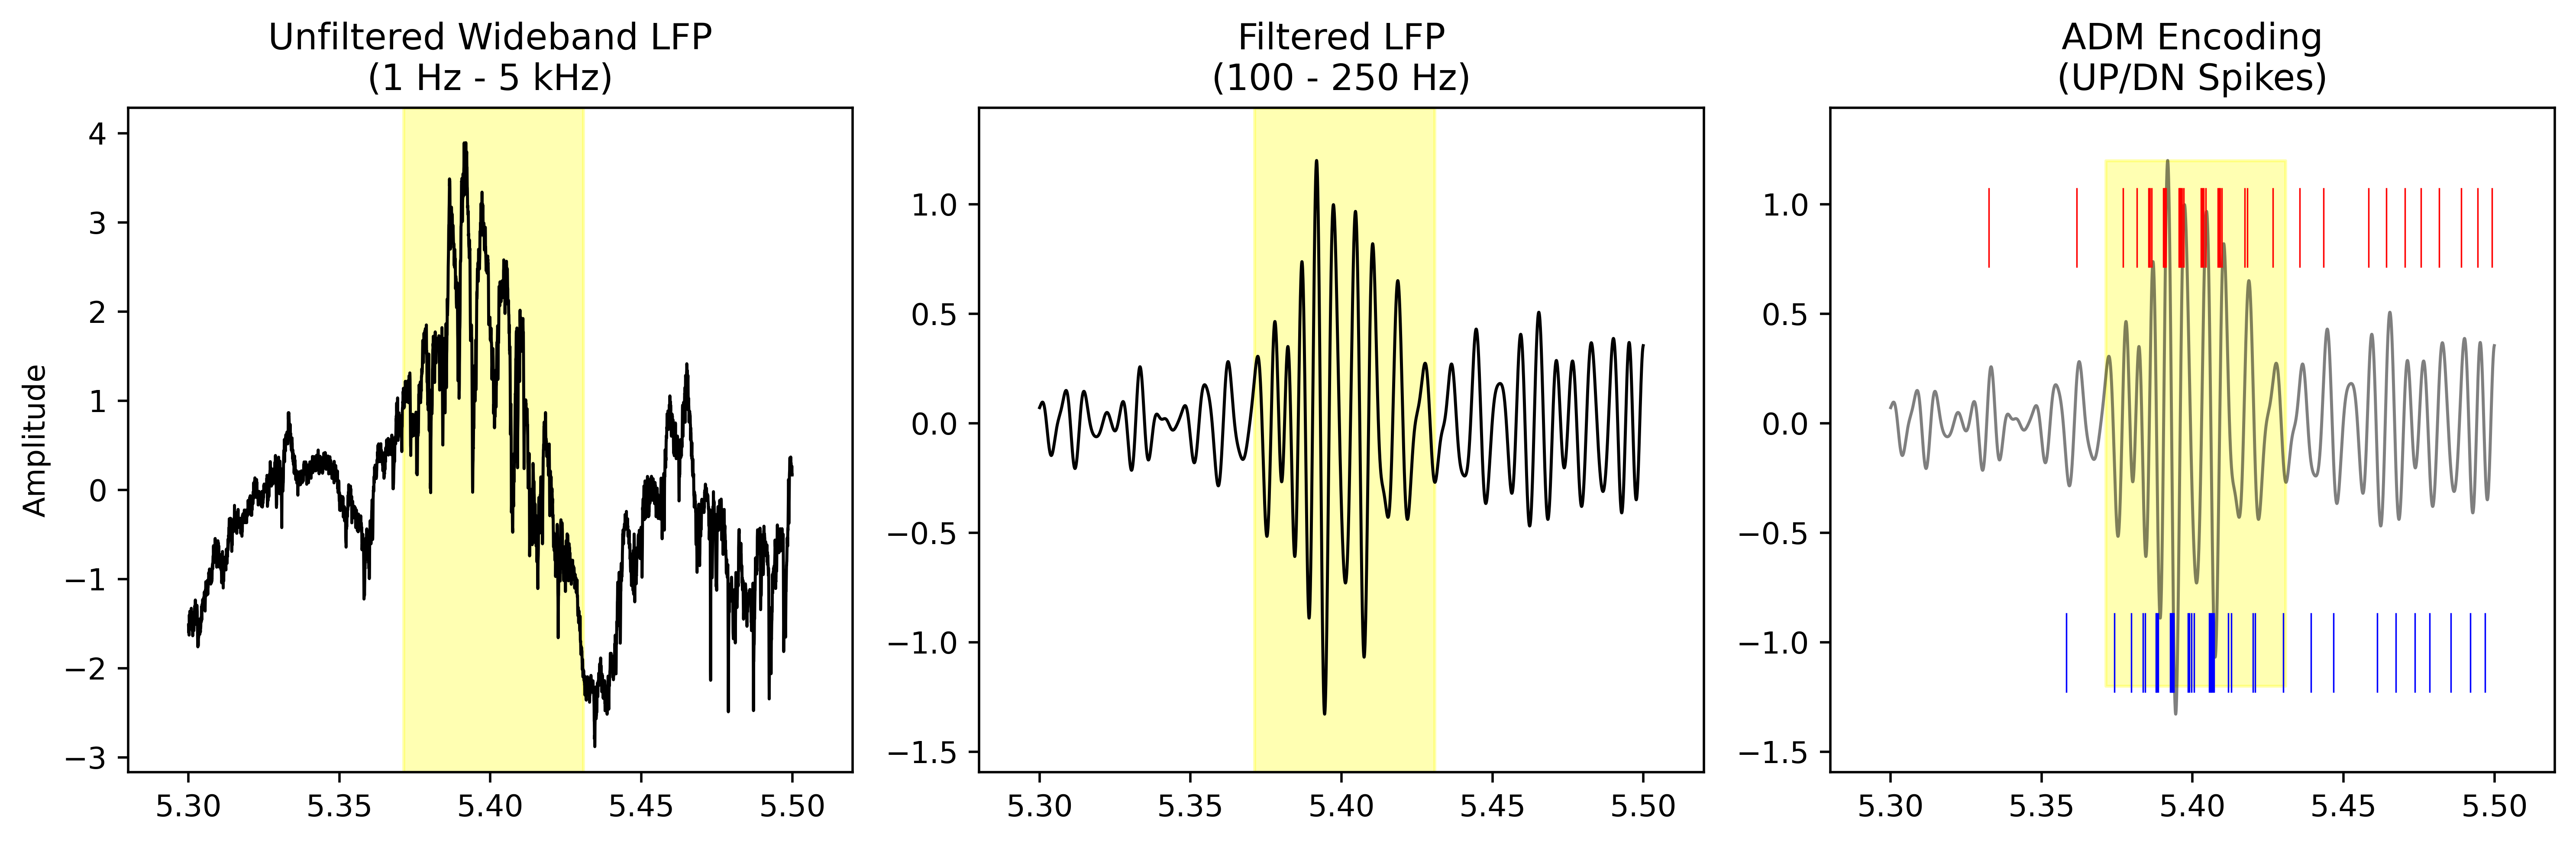

In [51]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=500, sharex=True)
window=[5.3,5.5]

start_index = int(window[0] * liset.fs)
end_index = int(window[1] * liset.fs)
time = np.arange(start_index, end_index) / liset.fs

# ----- First plot: Unfiltered Wideband LFP -----
data = channel_data[start_index:end_index]
min_data, max_data = np.min(data), np.max(data)
y_min, y_max = min_data * 1.1, max_data * 1.1

ax[0].plot(time, data, color='black', linewidth=1)
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs
    ax[0].fill_between([start, end], y_min, y_max, color="yellow", alpha=0.3,
                       label="GT Ripple" if i == 0 else None)

ax[0].set_xlim(window[0]-0.02, window[1]+0.02)
ax[0].set_ylim(y_min, y_max)
# ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title("Unfiltered Wideband LFP\n(1 Hz - 5 kHz)")
# ax[0].legend()
# ax[0].grid(axis="x",visible=True, linewidth=0.7,linestyle=":",alpha=0.7)  # <-- Add grid

# ----- Second plot: Filtered Ripple Band -----
filtered_data = filtered_channel[start_index:end_index]
time = np.arange(start_index, end_index) / liset.fs
min_data, max_data = np.min(filtered_data), np.max(filtered_data)
y_min= min_data * 1.2
y_max= max_data * 1.2
ax[1].plot(time, filtered_data, color='black', linewidth=1)
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs
    ax[1].fill_between([start, end], y_min, y_max, color="yellow", alpha=0.3,
                       label="GT Ripple" if i == 0 else None)
ax[1].set_ylim(y_min, y_max)
# ax[1].set_xlabel("Time (s)")
# ax[1].set_ylabel("Amplitude")
ax[1].set_title("Filtered LFP\n(100 - 250 Hz)")
# ax[1].legend()

# ----- Third plot: ADM Encoding (UP/DN) -----
up_down_window = up_down[start_index:end_index, :]
up_mask = up_down_window[:, 0] > 0
down_mask = up_down_window[:, 1] > 0
up_spike_times = time[up_mask]
down_spike_times = time[down_mask]

spike_height = (y_max - y_min) * 0.12
ax[2].plot(time, filtered_data, color='black', linewidth=1,alpha=0.5)
ax[2].vlines(down_spike_times, ymin=(y_min+spike_height), ymax=y_min+2*spike_height, color='blue', linewidth=0.5)
ax[2].vlines(up_spike_times, ymin=y_max-2*spike_height, ymax=y_max-spike_height, color='red', linewidth=0.5)
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs
    ax[2].fill_between([start, end], -1.2, 1.2, color="yellow", alpha=0.3,
                       label="GT Ripple" if i == 0 else None)


# ax[2].set_xlabel("Time (s)")
# ax[2].set_ylabel("Amplitude (uV)")
ax[2].set_title("ADM Encoding\n(UP/DN Spikes)")
# ax[2].set_yticks([-0.5, 0.5])
# ax[2].set_yticklabels(["DN", "UP"])
# ax[2].legend()  # Optional
ax[2].set_ylim(y_min, y_max)
# ----- Layout and Save -----
plt.tight_layout()
# fig.savefig(os.path.join(curr_dir, "pngs", "ripple_composite.png"), dpi=300)
plt.show()


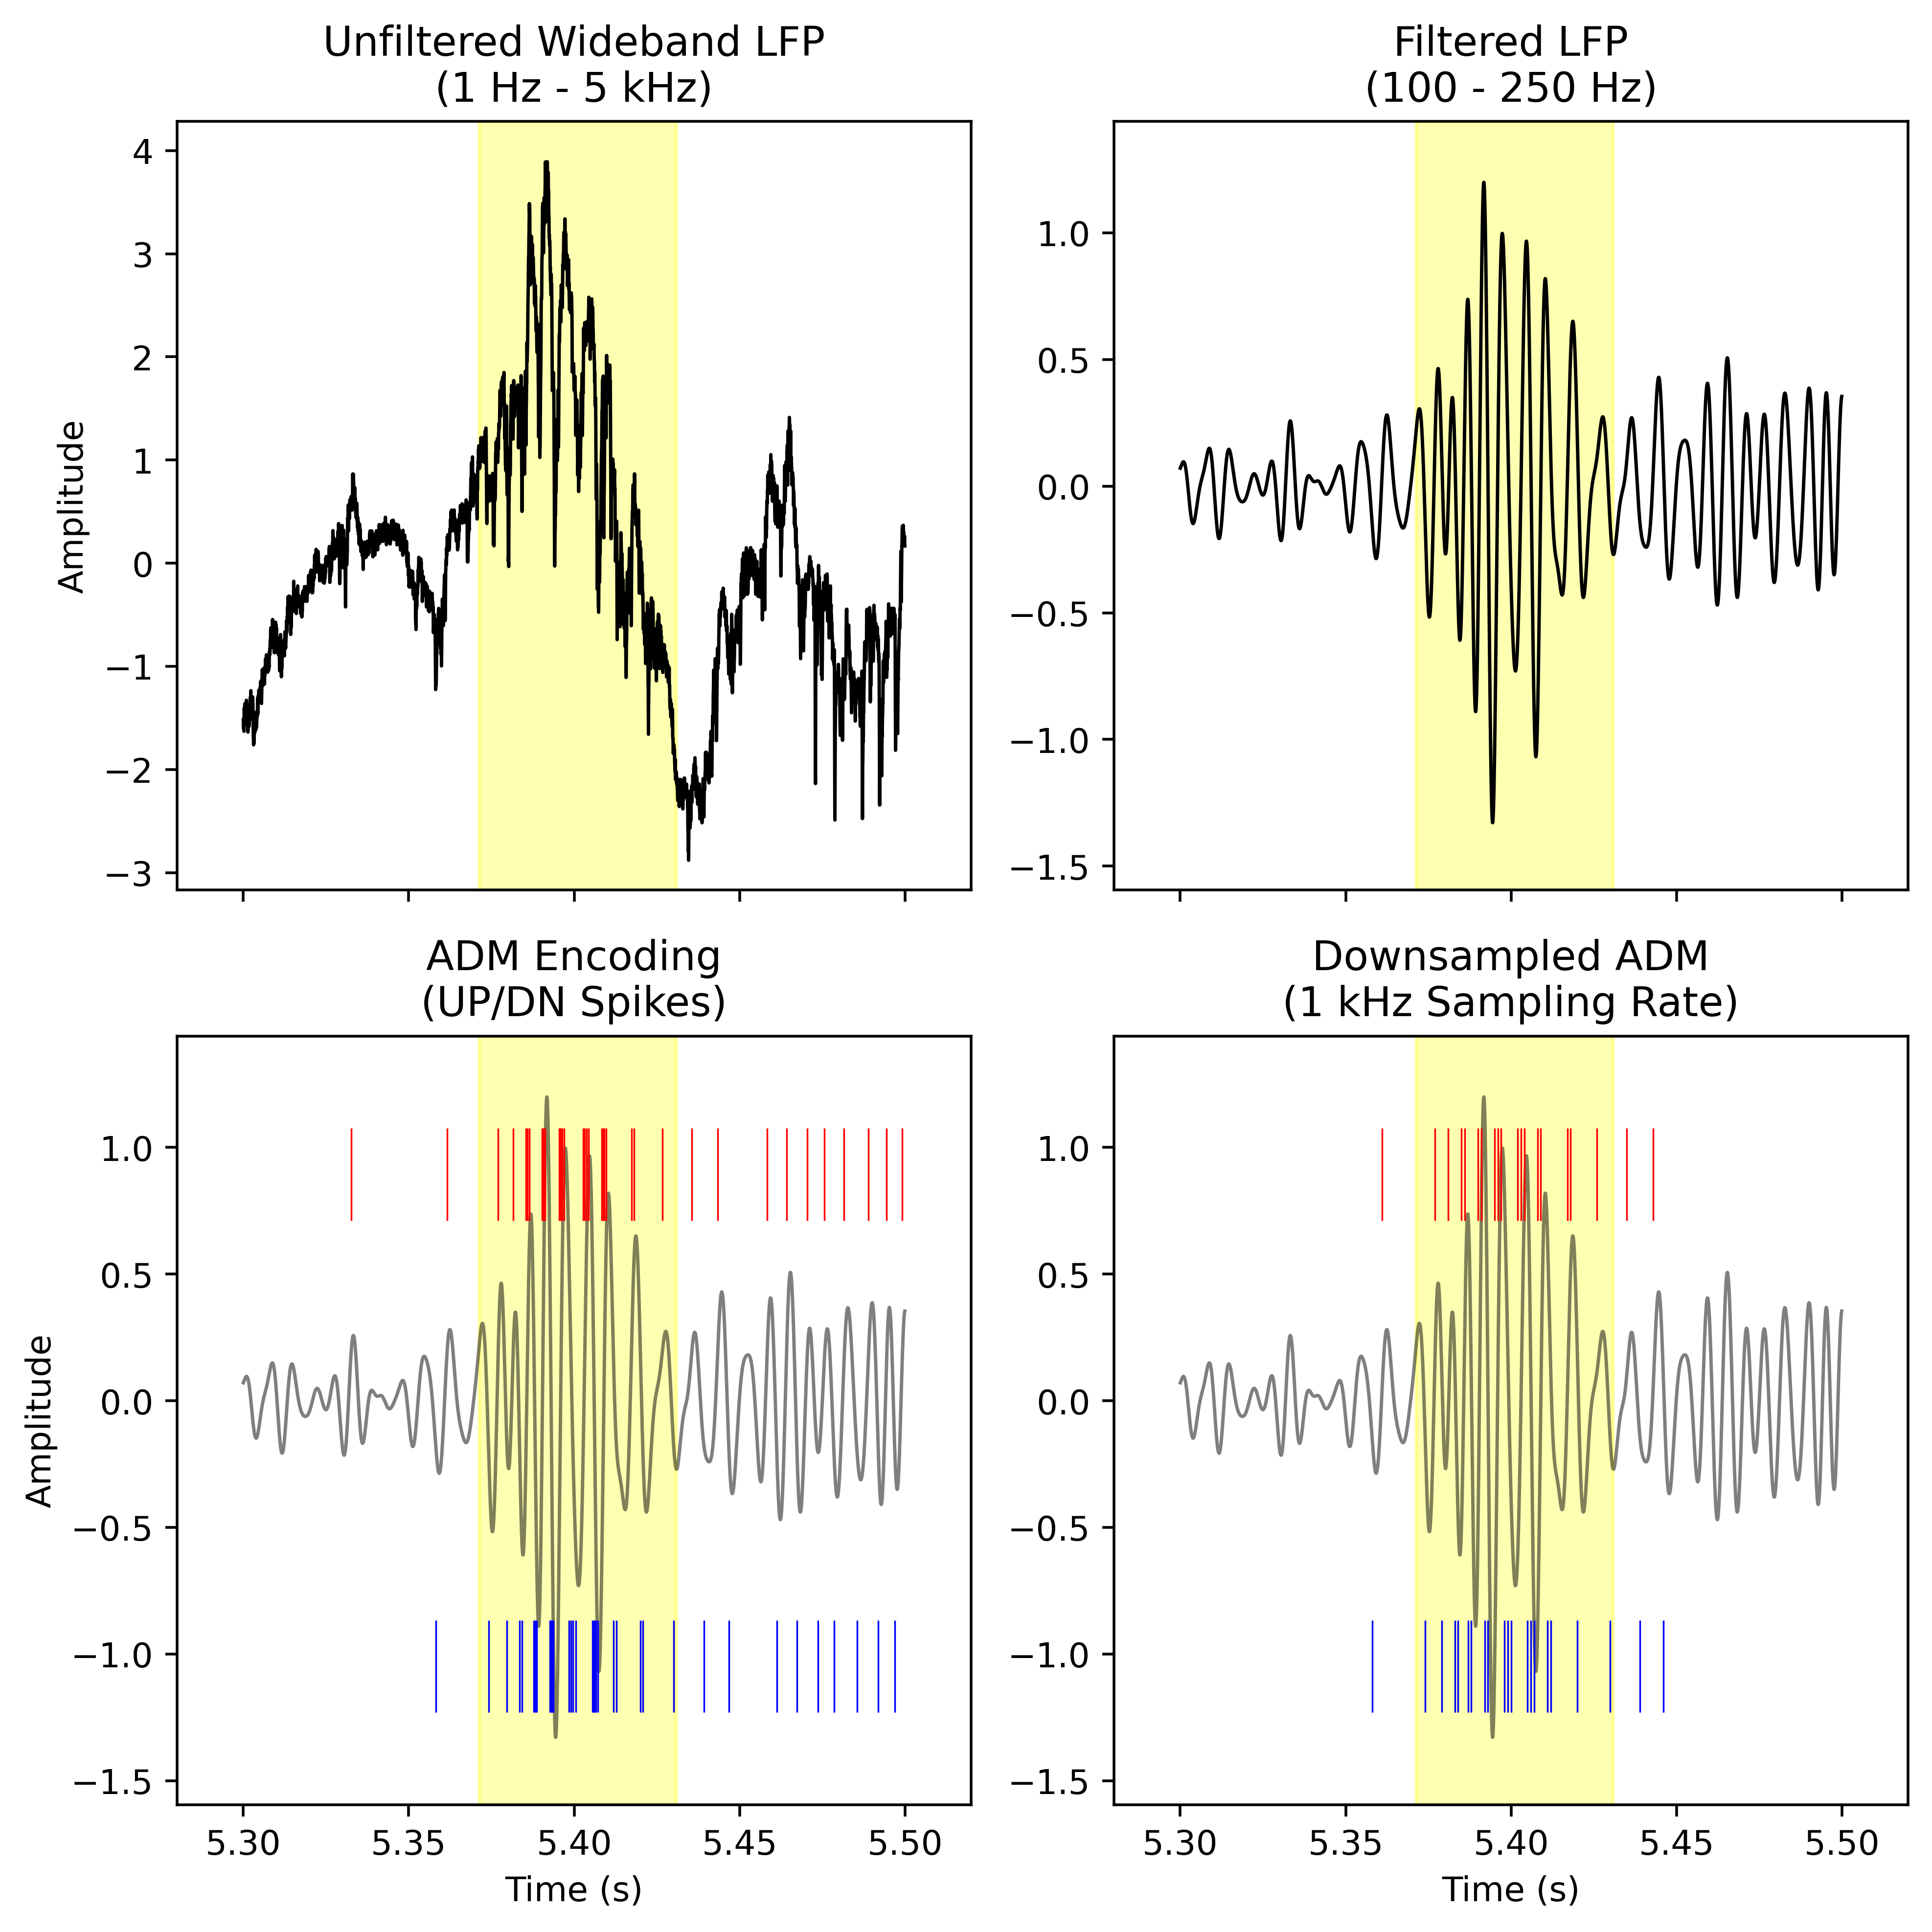

In [52]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=500, sharex=True)

# -----------------------------
# Common setup
start_index = int(window[0] * liset.fs)
end_index = int(window[1] * liset.fs)
time = np.arange(start_index, end_index) / liset.fs

# -----------------------------
# Plot (0,0): Unfiltered Wideband LFP
data = channel_data[start_index:end_index]
min_data, max_data = np.min(data), np.max(data)
y_min, y_max = min_data * 1.1, max_data * 1.1

ax[0, 0].plot(time, data, color='black', linewidth=1)
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs
    ax[0, 0].fill_between([start, end], y_min, y_max, color="yellow", alpha=0.3,
                          label="GT Ripple" if i == 0 else None)

ax[0, 0].set_xlim(window[0] - 0.02, window[1] + 0.02)
ax[0, 0].set_ylim(y_min, y_max)
ax[0, 0].set_ylabel("Amplitude")
ax[0, 0].set_title("Unfiltered Wideband LFP\n(1 Hz - 5 kHz)")
# ax[0, 0].legend()

# -----------------------------
# Plot (0,1): Filtered Ripple Band
filtered_data = filtered_channel[start_index:end_index]
min_data, max_data = np.min(filtered_data), np.max(filtered_data)
y_min = min_data * 1.2
y_max = max_data * 1.2

ax[0, 1].plot(time, filtered_data, color='black', linewidth=1)
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs
    ax[0, 1].fill_between([start, end], y_min, y_max, color="yellow", alpha=0.3,
                          label="GT Ripple" if i == 0 else None)
ax[0, 1].set_ylim(y_min, y_max)
ax[0, 1].set_title("Filtered LFP\n(100 - 250 Hz)")

# -----------------------------
# Plot (1,0): ADM Encoding (UP/DN)
up_down_window = up_down[start_index:end_index, :]
up_mask = up_down_window[:, 0] > 0
down_mask = up_down_window[:, 1] > 0
up_spike_times = time[up_mask]
down_spike_times = time[down_mask]

spike_height = (y_max - y_min) * 0.12
ax[1, 0].plot(time, filtered_data, color='black', linewidth=1, alpha=0.5)
ax[1, 0].vlines(down_spike_times, ymin=(y_min + spike_height), ymax=y_min + 2 * spike_height, color='blue', linewidth=0.5)
ax[1, 0].vlines(up_spike_times, ymin=y_max - 2 * spike_height, ymax=y_max - spike_height, color='red', linewidth=0.5)
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs
    ax[1, 0].fill_between([start, end], y_min, y_max, color="yellow", alpha=0.3,
                          label="GT Ripple" if i == 0 else None)

ax[1, 0].set_ylim(y_min, y_max)
ax[1, 0].set_xlabel("Time (s)")
ax[1, 0].set_ylabel("Amplitude")
ax[1, 0].set_title("ADM Encoding\n(UP/DN Spikes)")

# -----------------------------
# Plot (1,1): Downsampled Spikes (1 kHz)
window_downsample = [5.35, 5.45]
start_ds = int(window_downsample[0] * 1000)
end_ds = int(window_downsample[1] * 1000)
up_down_ds_window_downsample = spikes_downsample[start_ds:end_ds, :]

time_ds = np.arange(start_ds, end_ds) / 1000
spikes_up_mask = up_down_ds_window_downsample[:, 0] > 0
spikes_down_mask = up_down_ds_window_downsample[:, 1] > 0
up_spike_times = time_ds[spikes_up_mask]
down_spike_times = time_ds[spikes_down_mask]

ax[1, 1].plot(time, filtered_data, color='black', linewidth=1, alpha=0.5)
ax[1, 1].vlines(down_spike_times, ymin=(y_min + spike_height), ymax=y_min + 2 * spike_height, color='blue', linewidth=0.5)
ax[1, 1].vlines(up_spike_times, ymin=y_max - 2 * spike_height, ymax=y_max - spike_height, color='red', linewidth=0.5)

start_r, end_r = window_ripples[0] / liset.fs
ax[1, 1].fill_between([start_r, end_r], y_min,y_max, color="yellow", alpha=0.3, label="GT Ripple")

# ax[1, 1].set_yticks([-0.5, 0.5])
# ax[1, 1].set_yticklabels(["DN", "UP"])
ax[1, 1].set_title("Downsampled ADM\n(1 kHz Sampling Rate)")
ax[1, 1].set_xlabel("Time (s)")
ax[1, 1].set_ylim(y_min, y_max)
# ax[1, 1].legend()  # Optional

# -----------------------------
plt.tight_layout()
# plt.savefig("your_save_path.png", dpi=500)
plt.show()


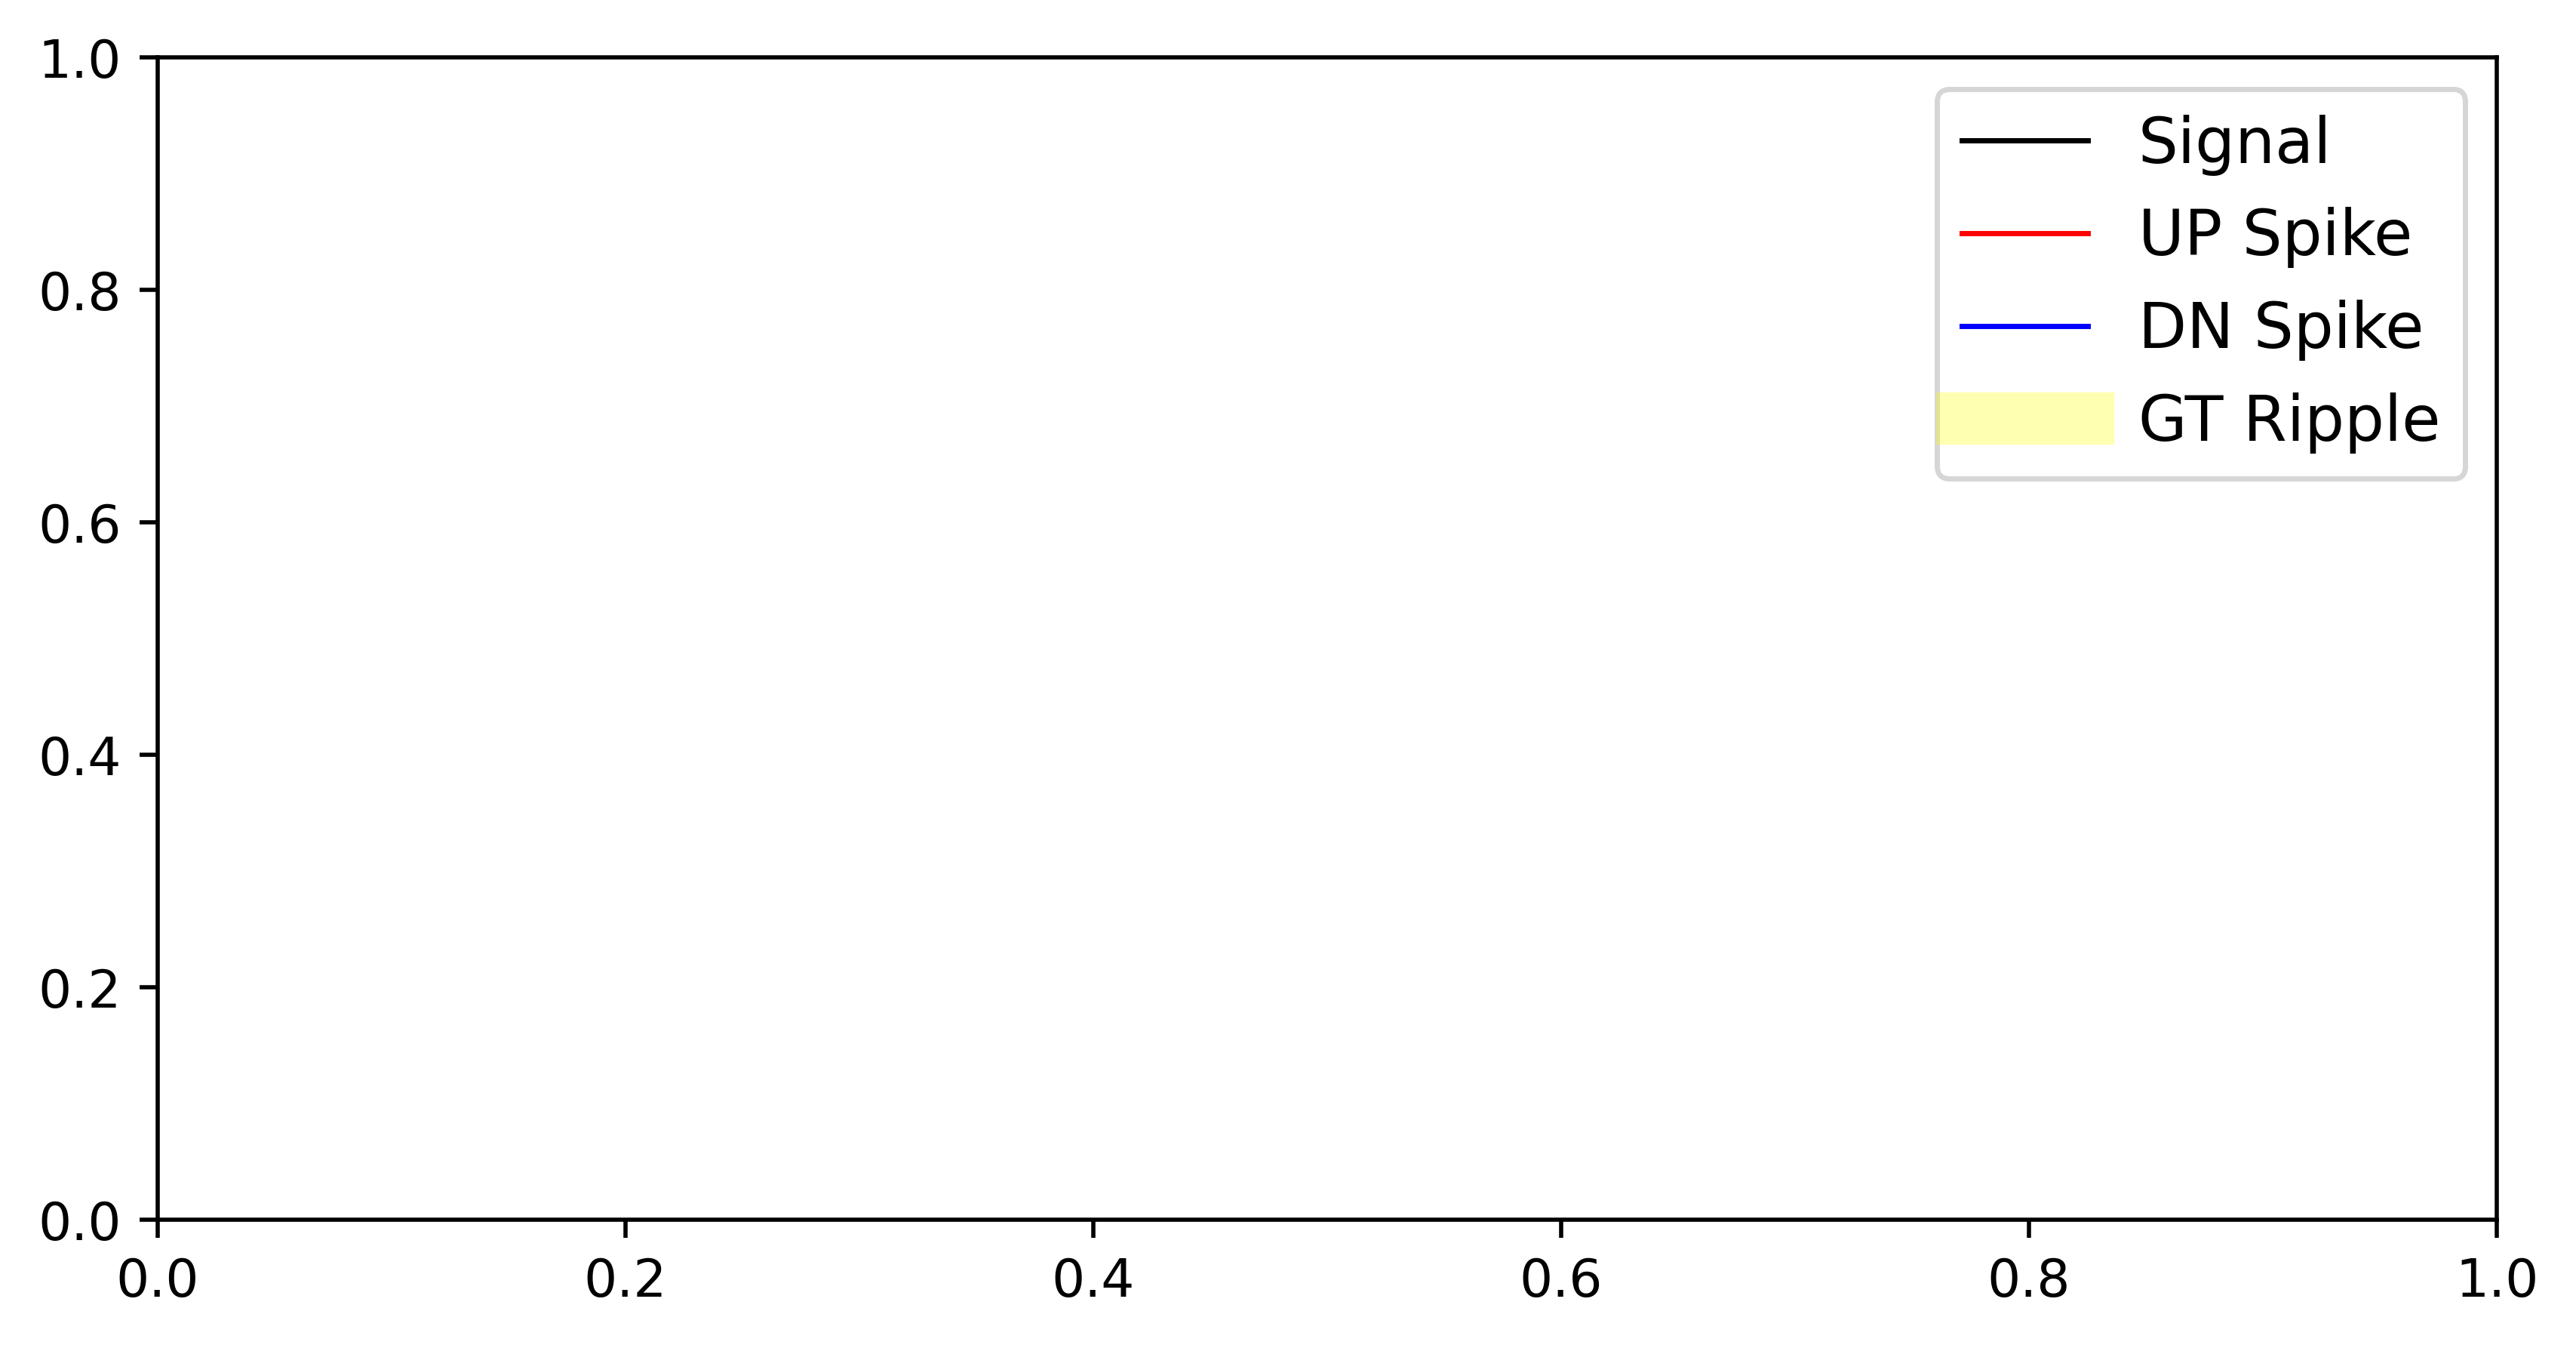

In [54]:
plt.figure(figsize=(8, 4), dpi=500)
# Plot dummy lines to create legend handles
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=1, label='Signal'),
    Line2D([0], [0], color='red', lw=1, label='UP Spike'),
    Line2D([0], [0], color='blue', lw=1, label='DN Spike'),
    Line2D([0], [0], color='yellow', lw=10, alpha=0.3, label='GT Ripple')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

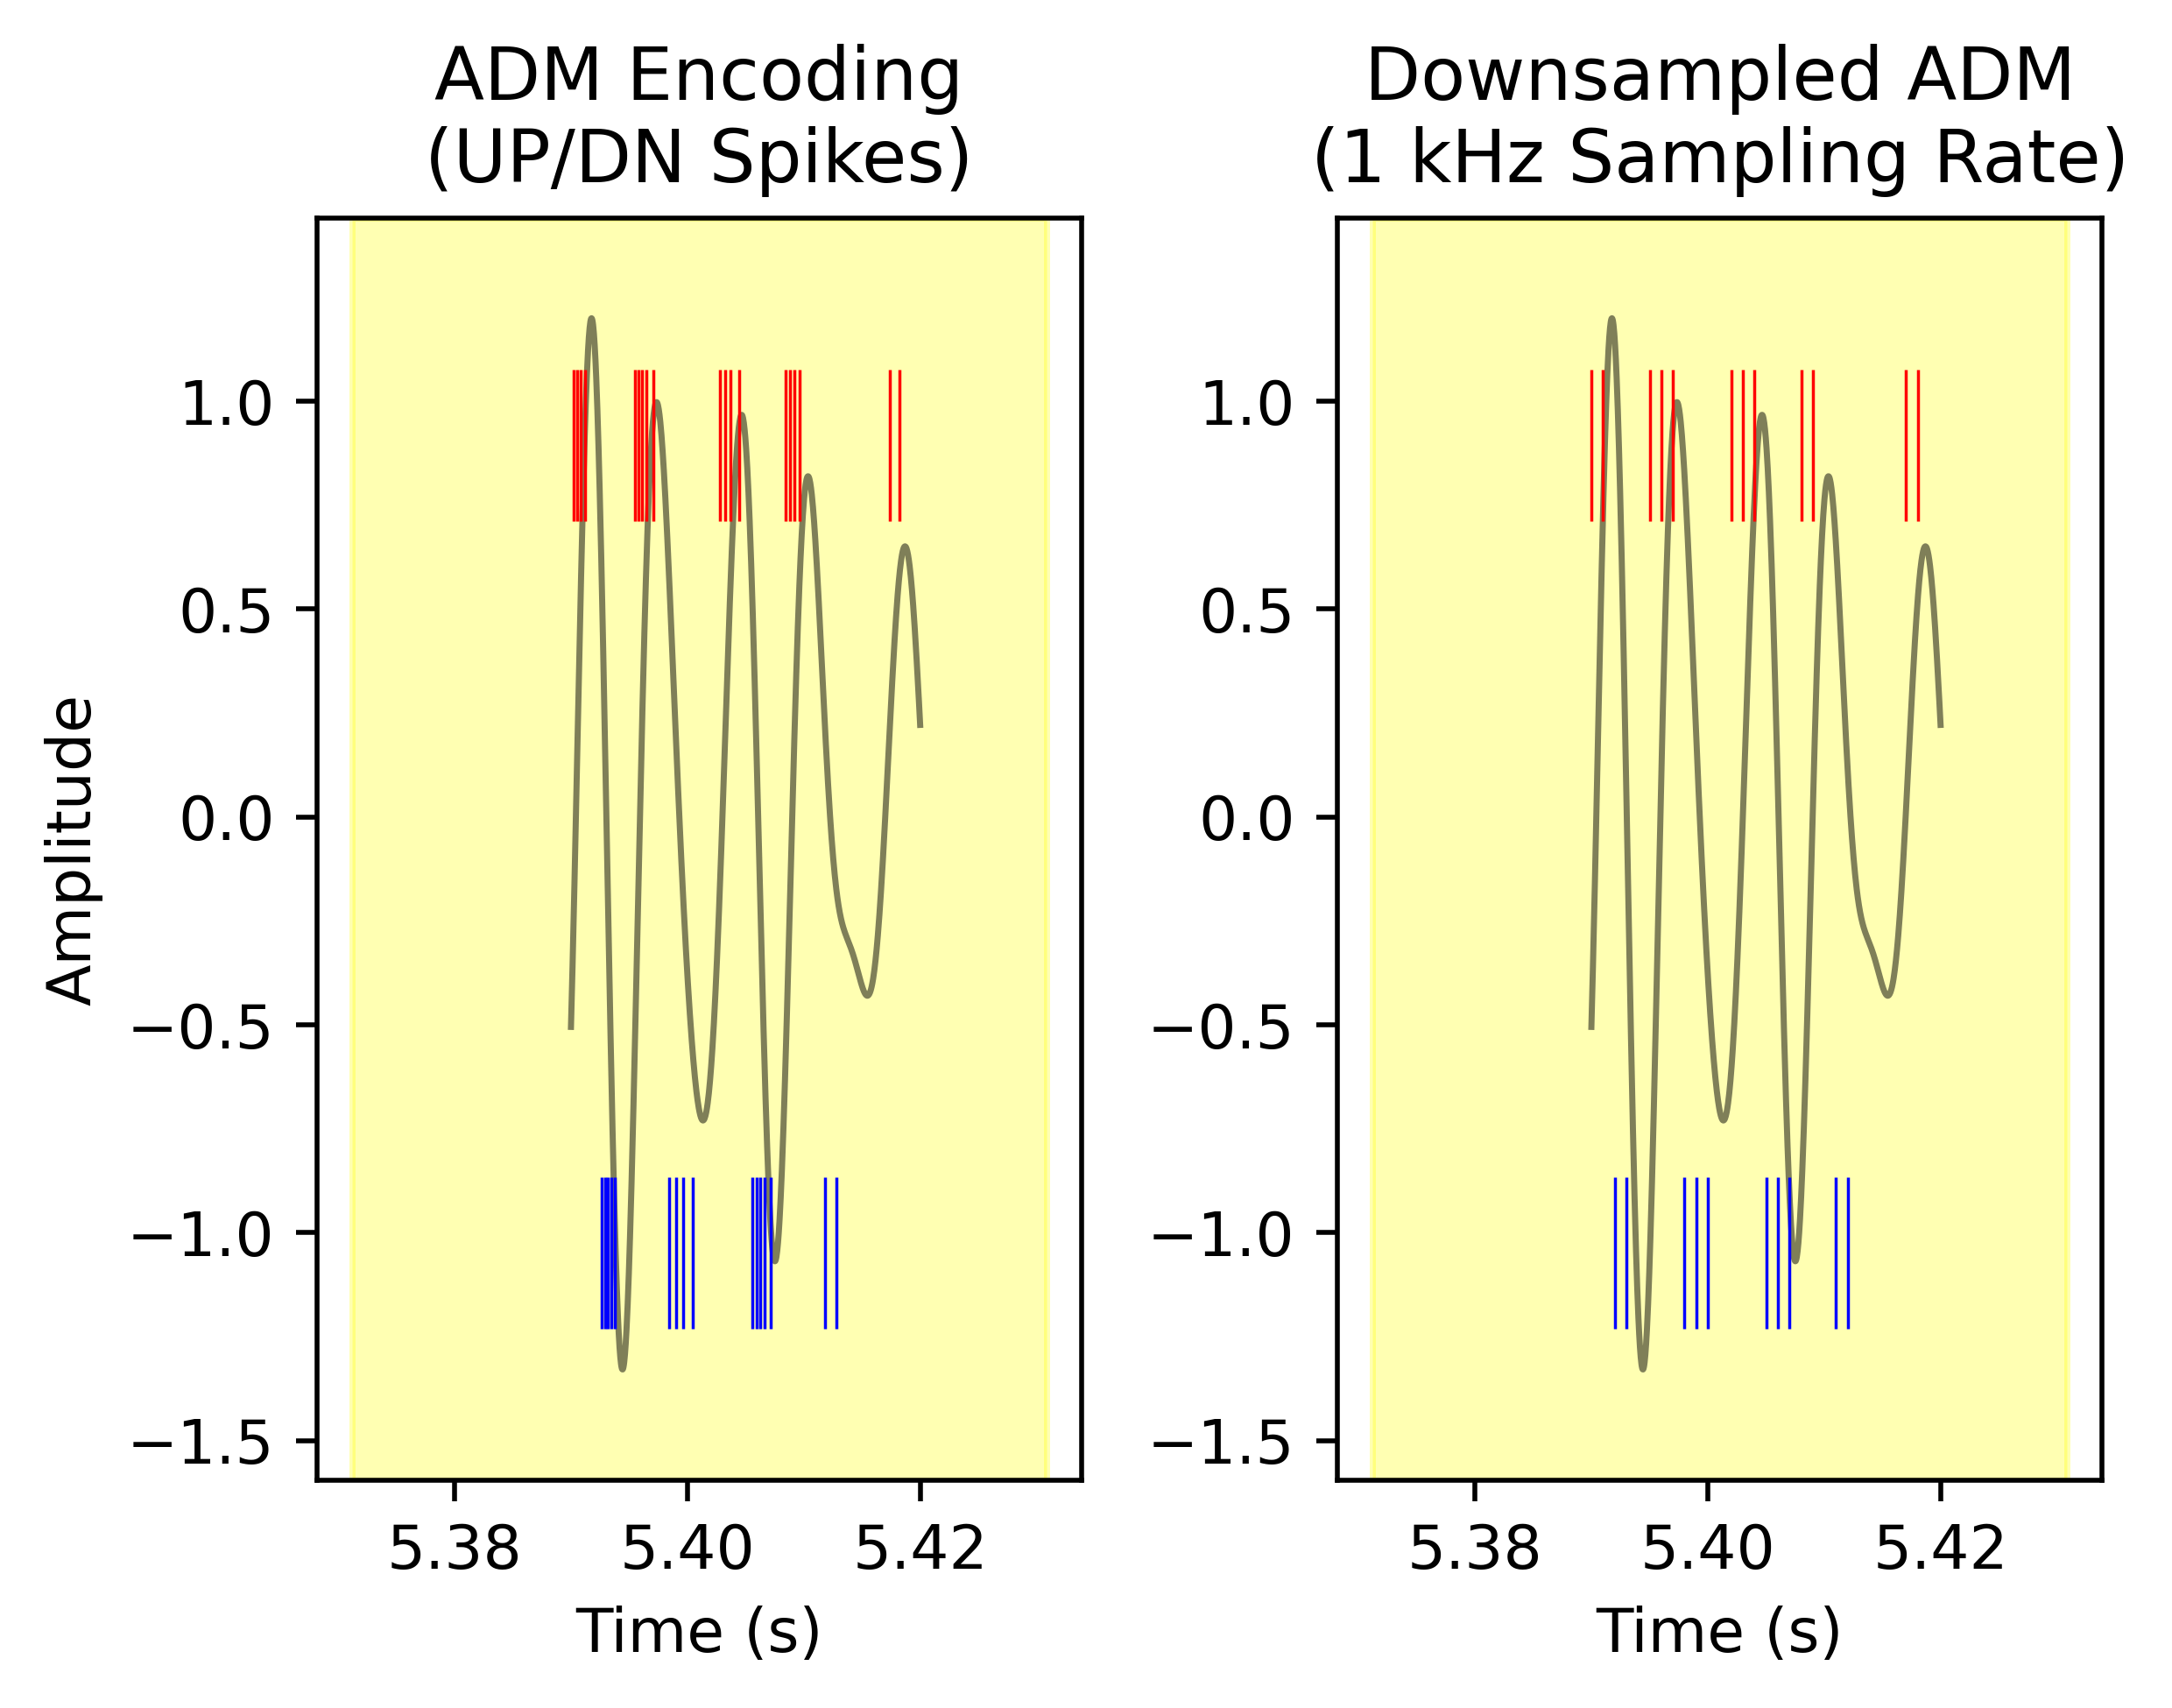

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(5, 4), dpi=500, sharex=True)

# -----------------------------
# Common setup
window= [5.39, 5.42]  # in seconds
start_index = int(window[0] * liset.fs)
end_index = int(window[1] * liset.fs)
time = np.arange(start_index, end_index) / liset.fs
filtered_data = filtered_channel[start_index:end_index]

# -----------------------------
# Plot (1,0): ADM Encoding (UP/DN)
up_down_window = up_down[start_index:end_index, :]
up_mask = up_down_window[:, 0] > 0
down_mask = up_down_window[:, 1] > 0
up_spike_times = time[up_mask]
down_spike_times = time[down_mask]

spike_height = (y_max - y_min) * 0.12
ax[0].plot(time, filtered_data, color='black', linewidth=1, alpha=0.5)
ax[0].vlines(down_spike_times, ymin=(y_min + spike_height), ymax=y_min + 2 * spike_height, color='blue', linewidth=0.5)
ax[0].vlines(up_spike_times, ymin=y_max - 2 * spike_height, ymax=y_max - spike_height, color='red', linewidth=0.5)
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs
    ax[0].fill_between([start, end], y_min, y_max, color="yellow", alpha=0.3,
                          label="GT Ripple" if i == 0 else None)

ax[0].set_ylim(y_min, y_max)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title("ADM Encoding\n(UP/DN Spikes)")

# -----------------------------
# Plot (1,1): Downsampled Spikes (1 kHz)
window_downsample = window
start_ds = int(window_downsample[0] * 1000)
end_ds = int(window_downsample[1] * 1000)
up_down_ds_window_downsample = spikes_downsample[start_ds:end_ds, :]

time_ds = np.arange(start_ds, end_ds) / 1000
spikes_up_mask = up_down_ds_window_downsample[:, 0] > 0
spikes_down_mask = up_down_ds_window_downsample[:, 1] > 0
up_spike_times = time_ds[spikes_up_mask]
down_spike_times = time_ds[spikes_down_mask]

ax[1].plot(time, filtered_data, color='black', linewidth=1, alpha=0.5)
ax[1].vlines(down_spike_times, ymin=(y_min + spike_height), ymax=y_min + 2 * spike_height, color='blue', linewidth=0.5)
ax[1].vlines(up_spike_times, ymin=y_max - 2 * spike_height, ymax=y_max - spike_height, color='red', linewidth=0.5)

start_r, end_r = window_ripples[0] / liset.fs
ax[1].fill_between([start_r, end_r], y_min,y_max, color="yellow", alpha=0.3, label="GT Ripple")

# ax[1, 1].set_yticks([-0.5, 0.5])
# ax[1, 1].set_yticklabels(["DN", "UP"])
ax[1].set_title("Downsampled ADM\n(1 kHz Sampling Rate)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylim(y_min, y_max)
# ax[1, 1].legend()  # Optional

# -----------------------------
plt.tight_layout()
# plt.savefig("your_save_path.png", dpi=500)
plt.show()
